# Lambda Functions – Simple Examples

We work through each `*FromLambda` component one by one.
At the end we wire them together into a complete optimisation.

In [6]:
import numpy as np
import metaheuristic_designer as mhd
import seaborn as sns
import matplotlib.pyplot as plt

rng = mhd.check_random_state(42)

## 1. Objective function (Rastrigin)

`ObjectiveFromLambda` takes any function that receives a solution vector
and returns a fitness value.

In [7]:
def rastrigin(x, A=10.0):
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))


objfunc = mhd.ObjectiveFromLambda(
    obj_func=rastrigin,
    mode="min",
    name="Rastrigin",
    A=10.0,  # extra kwargs are forwarded
)

Check the function with a test value

In [8]:
objfunc.objective(np.array([1.0, 2.0]))  # quick sanity check

np.float64(5.0)

## 2. Initializer (uniform random)

`InitializerFromLambda` receives a function `(random_state)` that returns
a single solution vector.

In [9]:
DIM = 5
init = mhd.InitializerFromLambda(
    vecsize=DIM,
    generator=lambda rs: rs.uniform(-5.12, 5.12, size=DIM),
    pop_size=100,
    random_state=rng,
)

Check generating a random individual

In [10]:
print(init.generate_random())

[ 2.80530994 -0.62588478  3.6720427   2.02104862 -4.15562396]


## 3. Operator – simple Gaussian mutation

`OperatorFromLambda` has signature
`(population, initializer, random_state, **kwargs)`.
It must return a `Population`.  We add zero‑mean noise to every gene.

In [11]:
def gaussian_mutation(population, initializer, random_state, scale=0.1):
    noise = random_state.normal(0, scale, size=population.genotype_matrix.shape)
    return population.update_genotype(population.genotype_matrix + noise)


mut_op = mhd.OperatorFromLambda(
    operator_fn=gaussian_mutation,
    name="GaussMut",
    random_state=rng,
    scale=0.5,
)

Check by mutating a random population

In [12]:
test_pop = init.generate_population(objfunc=objfunc, n_individuals=2)
display(test_pop.genotype_matrix)
mut_test = mut_op.evolve(test_pop)
display(mut_test.genotype_matrix)

array([[ 4.87037288,  2.67407055,  2.92929849, -3.8081164 , -0.508048  ],
       [-1.32302823,  4.37007349,  1.47317883,  3.30507892, -0.5794386 ]])

array([[ 4.44072665,  2.85844594,  2.44985719, -3.36889125, -0.53301095],
       [-1.41545941,  4.02960871,  2.0844495 ,  3.22781418, -0.79360252]])

## 4. Parent selection – tournament

`ParentSelectionFromLambda` expects `(population, amount, random_state, **kwargs)`.
It returns indices of selected individuals.

In [13]:
def tournament_sel(population, amount, random_state, size=3):
    n = len(population.fitness)
    pool = random_state.integers(0, n, size=(amount, size))
    best = np.argmax(population.fitness[pool], axis=1)
    return pool[np.arange(amount), best]


parent_sel = mhd.parent_selection.ParentSelectionFromLambda(
    selection_fn=tournament_sel,
    amount=10,  # select half of pop
    random_state=rng,
    size=3,
)

## 5. Survivor selection – (mu+lambda)

`SurvivorSelectionFromLambda` receives two `Population` objects and a
random state.  We keep the best `pop_size` individuals from the combined
group.

In [14]:
def mu_plus_lambda(population, offspring, random_state):
    """Select the best `len(population)` individuals from parents + offspring."""
    total_fit = np.concatenate([population.fitness, offspring.fitness])
    n = len(population)
    # Sort descending (higher fitness = better, irrespective of min/max mode)
    best_idx = np.argsort(total_fit)[::-1][:n]
    return best_idx


survivor_sel = mhd.SurvivorSelectionFromLambda(
    selection_fn=mu_plus_lambda,
    random_state=rng,
)

## 6. Encoding – identity

`EncodingFromLambda` wraps encode/decode functions.  The identity
encoding passes data through unchanged.

In [15]:
encoding = mhd.EncodingFromLambda(
    encode_fn=lambda x: x,
    decode_fn=lambda x: x,
)

## 7. Constraint handler – clip and penalty

`ConstraintHandlerFromLambda` can repair solutions and/or compute
penalties.  We clip to [-5.12, 5.12] and apply a quadratic penalty for
violations.  This is attached to the objective function.

In [16]:
constraint = mhd.ConstraintHandlerFromLambda(
    repair_solution_fn=lambda x: np.clip(x, -5.12, 5.12),
    penalty_fn=lambda x: 10.0 * np.sum(np.maximum(0, np.abs(x) - 5.12) ** 2),
)

# Re‑create the objective function with the constraint
objfunc = mhd.ObjectiveFromLambda(
    obj_func=rastrigin,
    constraint_handler=constraint,
    mode="min",
    name="Rastrigin (constrained)",
    A=10.0,
)

## 8. Build a search strategy

Because we already wrapped each component in its `*FromLambda` class, we
use the standard `SearchStrategy` constructor to assemble them.

In [17]:
strategy = mhd.SearchStrategy(
    name="custom strategy",
    initializer=init,
    operator=mut_op,
    parent_sel=parent_sel,
    survivor_sel=survivor_sel,
    encoding=encoding,
    random_state=rng,
)

## 9. Run the algorithm

In [18]:
algo = mhd.algorithms.Algorithm(objfunc, strategy, ngen=100, stop_cond="ngen", reporter="tqdm", verbose_timer=0)
population = algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 10. Results

In [19]:
solution, fitness = population.best_solution(problem_space=True)
print(f"Best fitness: {fitness}")
print(f"Best solution: {solution}")

Best fitness: 8.081400084716016
Best solution: [-3.06944917e-04  7.70144413e-02  6.15752761e-02 -1.69455578e-01
 -1.00140155e+00]


We can also visualize the convergence of the algorithm with the help of seaborn

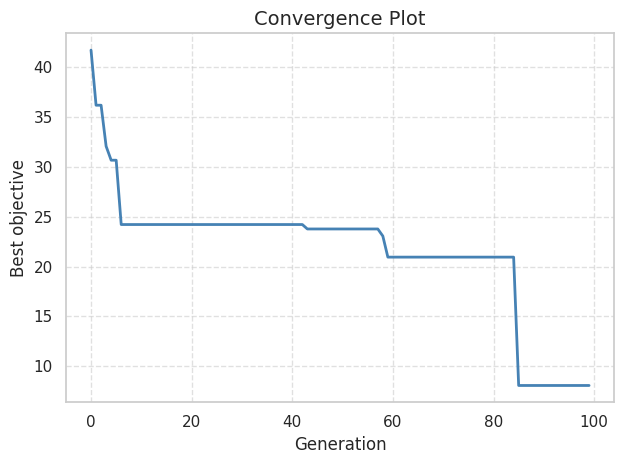

In [ ]:
# Dataframe with the tracked best objective value across generations.
history_data = algo.history_tracker.to_pandas()

# Plotting functionality.
sns.set_theme(style="whitegrid")
ax = sns.lineplot(history_data, x="iteration", y="best_objective", linewidth=2, color="steelblue")
ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Best objective", fontsize=12)
ax.set_title("Convergence Plot", fontsize=14)
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()